# 10 · Two-Pass Saliency Inference — Simplex Noise

Implements a **saliency-guided anomaly detection** pipeline on top of the trained
`diffusion_best.pt` / `diffusion_epoch0030.pt` checkpoint.

```
BraTS T1 slice  x₀
      │
      ├──── PASS 1: full-image DDPM ────────────────────────────────────────┐
      │     add noise to t=T_enc → DDPM reverse → x̂₀_rough               │
      │     anomaly_rough = |x₀ − x̂₀_rough|                               │
      │     saliency_mask = threshold(anomaly_rough)   ◄───────────────────┘
      │
      └──── PASS 2: hybrid DDIM/DDPM ─────────────────────────────────────┐
            add noise to t=T_enc → hybrid_sample() → x̂₀_clean            │
              • DDPM (stochastic) inside saliency_mask                     │
              • DDIM (deterministic) outside saliency_mask                 │
            anomaly_clean = |x₀ − x̂₀_clean|                               │
            ◄───────────────────────────────────────────────────────────────┘
```

**Flag**: set `USE_SALIENCY = False` to fall back to the original single-pass pipeline.

**Sections**
1. Imports & config
2. Data loading helpers (T1 + seg preprocessing)
3. Model definition & checkpoint loading
4. Schedulers
5. Pass 1 — full-image DDPM inference
6. Thresholding — Otsu vs fixed
7. `hybrid_sample` — per-pixel DDPM/DDIM blending
8. Pass 2 — saliency-guided hybrid inference
9. Full two-pass pipeline wrapper
10. Single-slice demo with visualisation
11. Batch evaluation (DSC, AUROC, pixel-AP)

## 1 · Imports & config

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset

from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDIMScheduler, DDPMScheduler

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── device ───────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.bfloat16   # matches training; change to float32 if no bfloat16 support
print(f'Device : {DEVICE}  |  dtype : {DTYPE}')

# ── paths ─────────────────────────────────────────────────────────────────────
def _find_dir(name):
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / name
        if p.exists():
            return p
    raise FileNotFoundError(f'{name!r} not found from {Path.cwd()}')

BRATS_ROOT = _find_dir('BraTS2020_TrainingData') / 'MICCAI_BraTS2020_TrainingData'
# prefer diffusion_best.pt; fall back to the epoch checkpoint
for _name in ['simplex_best_e0049.pt']:
    for _base in [Path.cwd(), *Path.cwd().parents]:
        _candidate = _base / _name
        if _candidate.exists():
            CKPT_PATH = _candidate
            break
    else:
        continue
    break
else:
    raise FileNotFoundError('No checkpoint found. Expected simplex_best_e0049.pt')

print(f'BraTS  : {BRATS_ROOT}')
print(f'Ckpt   : {CKPT_PATH}')

# ── pipeline flags ────────────────────────────────────────────────────────────
USE_SALIENCY   = True    # False → original single-pass DDPM pipeline
T_ENCODE     = 400
N_DDPM_STEPS = 400
N_DDIM_STEPS = 1000  # full denoise — cleaner recon   # more DDIM steps → sharper Pass 2 recon      # reverse steps for Pass 2 DDIM portion
SMOOTH_SIGMA   = 2.0     # Gaussian smoothing on anomaly maps (pixels)
THRESH_METHOD  = 'fixed'  # 'otsu' or 'fixed'
FIXED_THRESH   = 0.040    # used only when THRESH_METHOD == 'fixed'

## 2 · Data loading helpers

In [33]:
def preprocess_volume(nii_path, target_size=256,
                      z_low=0.15, z_high=0.85, fill_thresh=0.05):
    """
    Preprocess a T1w NIfTI volume into a list of 2D slice tensors.
    Matches training pipeline exactly.

    Returns
    -------
    slices : list of np.ndarray  shape (1, target_size, target_size), float32, [0,1]
    z_indices : list of int  -- original z-index for each returned slice
    """
    vol = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
    if vol.ndim != 3:
        return [], []

    nonzero = vol[vol != 0]
    if nonzero.size == 0:
        return [], []

    # percentile normalisation
    p_lo, p_hi = np.percentile(nonzero, [0.5, 99.5])
    vol = np.clip((vol - p_lo) / max(float(p_hi - p_lo), 1e-6), 0.0, 1.0)

    D = vol.shape[2]
    z0 = int(np.floor(D * z_low))
    z1 = int(min(np.ceil(D * z_high), D))

    slices, z_indices = [], []
    for zi in range(z0, z1):
        s = vol[:, :, zi]
        if np.count_nonzero(s) / s.size < fill_thresh:
            continue
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None])
            s = F.interpolate(t, (target_size, target_size),
                              mode='bilinear', align_corners=False).squeeze().numpy()
        slices.append(s[np.newaxis].astype(np.float32))   # (1, H, W)
        z_indices.append(zi)

    return slices, z_indices


def preprocess_seg(seg_path, z_indices, target_size=256):
    """
    Extract segmentation slices at the same z-indices returned by preprocess_volume.
    Labels: 0=background, 1=necrotic, 2=edema, 3=enhancing tumour.

    Returns
    -------
    seg_slices : list of np.ndarray  shape (1, target_size, target_size), int32
    """
    vol = nib.load(str(seg_path)).get_fdata(dtype=np.float32).astype(np.int32)
    seg_slices = []
    for zi in z_indices:
        s = vol[:, :, zi]
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None].astype(np.float32))
            s = F.interpolate(t, (target_size, target_size),
                              mode='nearest').squeeze().numpy().astype(np.int32)
        seg_slices.append(s[np.newaxis])   # (1, H, W)
    return seg_slices


def discover_brats_cases(brats_root):
    """
    Discover all BraTS cases that have both a T1 and a segmentation file.

    Returns
    -------
    cases : list of dict  keys: id, t1_path, seg_path
    """
    cases = []
    for case_dir in sorted(Path(brats_root).iterdir()):
        if not case_dir.is_dir():
            continue
        t1_files  = list(case_dir.glob('*_t1.nii'))
        seg_files = list(case_dir.glob('*_seg.nii'))
        if not t1_files or not seg_files:
            continue
        cases.append(dict(
            id       = case_dir.name,
            t1_path  = t1_files[0],
            seg_path = seg_files[0],
        ))
    return cases


class BraTSDataset(Dataset):
    """
    Flat dataset: one item per valid axial slice across all BraTS cases.
    Preprocessing is lazy (per-__getitem__) to stay RAM-friendly.
    """

    def __init__(self, cases, tumor_only=False):
        self.tumor_only = tumor_only
        self._cases   = cases
        self._index   = []
        self._indexed = False
        print(f'Indexing {len(cases)} BraTS cases (lazy -- fast) ...')

    def _build_index(self):
        self._index = []
        for case in self._cases:
            slices, z_idxs = preprocess_volume(case['t1_path'])
            if not slices:
                continue
            seg_slices = preprocess_seg(case['seg_path'], z_idxs)
            for sl, seg, zi in zip(slices, seg_slices, z_idxs):
                has_tumor = bool(seg.max() > 0)
                if self.tumor_only and not has_tumor:
                    continue
                self._index.append(dict(case=case, z_idx=zi, has_tumor=has_tumor))
        self._indexed = True
        print(f'Index built: {len(self._index)} slices '
              f'({sum(e["has_tumor"] for e in self._index)} with tumour)')

    def __len__(self):
        if not self._indexed:
            self._build_index()
        return len(self._index)

    def __getitem__(self, idx):
        if not self._indexed:
            self._build_index()
        entry = self._index[idx]
        case  = entry['case']
        zi    = entry['z_idx']
        slices, z_idxs = preprocess_volume(case['t1_path'])
        pos = z_idxs.index(zi)
        image_arr  = slices[pos]
        seg_slices = preprocess_seg(case['seg_path'], [zi])
        seg_arr    = seg_slices[0]
        return {
            'image'    : torch.from_numpy(image_arr),
            'seg'      : seg_arr,
            'case'     : case['id'],
            'z_idx'    : zi,
            'has_tumor': entry['has_tumor'],
        }


def brats_collate(batch):
    return {
        'image'    : torch.stack([b['image'] for b in batch]),
        'seg'      : np.stack([b['seg'] for b in batch]),
        'case'     : [b['case'] for b in batch],
        'z_idx'    : [b['z_idx'] for b in batch],
        'has_tumor': [b['has_tumor'] for b in batch],
    }


# ── discover cases ────────────────────────────────────────────────────────────
all_cases = discover_brats_cases(BRATS_ROOT)
print(f'Found {len(all_cases)} BraTS cases')

# ── sanity check: preprocess first case ──────────────────────────────────────
case0 = all_cases[0]
slices0, z0 = preprocess_volume(case0['t1_path'])
segs0        = preprocess_seg(case0['seg_path'], z0)
tumor_load   = [s.sum() for s in segs0]
best_z       = int(np.argmax(tumor_load))

print(f'Case         : {case0["id"]}')
print(f'Valid slices : {len(slices0)}  (z={z0[0]}..{z0[-1]})')
print(f'Slices with tumour : {sum(1 for s in segs0 if s.max() > 0)} / {len(segs0)}')
print(f'Best z for demo    : {z0[best_z]}')
print('preprocess_volume, preprocess_seg, discover_brats_cases, BraTSDataset, brats_collate defined.')


Found 5 BraTS cases
Case         : BraTS20_Training_001
Valid slices : 107  (z=23..129)
Slices with tumour : 83 / 107
Best z for demo    : 67
preprocess_volume, preprocess_seg, discover_brats_cases, BraTSDataset, brats_collate defined.


## 3 · Model definition & checkpoint loading

In [ ]:
# Architecture must match the saved checkpoint exactly.
# simplex_best_e0049.pt was trained with simplex noise:
#   channels=(64,128,256,512), attention_levels=(False,False,False,True),
#   num_res_blocks=1, out_channels=1
unet = DiffusionModelUNet(
    spatial_dims     = 2,
    in_channels      = 1,
    out_channels     = 1,
    channels         = (64, 128, 256, 512),
    attention_levels = (False, False, False, True),
    num_res_blocks   = 1,
    num_head_channels= 32,
    norm_num_groups  = 32,
).to(DEVICE)

total_params = sum(p.numel() for p in unet.parameters())
print(f'Model: {total_params/1e6:.2f} M parameters')

# ── load checkpoint ───────────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

# support both 'unet' and 'unet_full' key names
state_key = 'unet' if 'unet' in ckpt else 'unet_full'
missing, unexpected = unet.load_state_dict(ckpt[state_key], strict=True)
if missing:     print(f'WARNING missing   : {missing[:5]}')
if unexpected:  print(f'WARNING unexpected: {unexpected[:5]}')

epoch_loaded = ckpt.get('epoch', '?')
print(f'Loaded epoch {epoch_loaded} from {CKPT_PATH.name}  (noise_type={ckpt.get("noise_type", "simplex")}, octaves={ckpt.get("simplex_octaves", 6)})')

# cast to bfloat16 (matches training)
unet = unet.to(DTYPE).eval()
print(f'Model dtype: {next(unet.parameters()).dtype}')

## 4 · Schedulers

In [35]:
T = 1000
_sched_kwargs = dict(
    num_train_timesteps = T,
    schedule            = 'linear_beta',
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)

ddpm_scheduler = DDPMScheduler(**_sched_kwargs)
ddim_scheduler = DDIMScheduler(**_sched_kwargs)

print(f'DDPM scheduler ready  (T={T})')
print(f'DDIM scheduler ready  (T={T})')

DDPM scheduler ready  (T=1000)
DDIM scheduler ready  (T=1000)


## 4b · Simplex noise generator

Replaces  in both Pass 1 and Pass 2 with spatially-correlated fractal noise, matching the training distribution of .

In [ ]:
# ── Simplex (fractal) noise ───────────────────────────────────────────────────
# Spatially-correlated noise that better matches blob-like tumour structure.
# Reference: Wolleb et al. "Diffusion Models for Medical Anomaly Detection" (2022)

SIMPLEX_OCTAVES = ckpt.get('simplex_octaves', 6)   # read from checkpoint


def generate_simplex_noise(shape, octaves=SIMPLEX_OCTAVES, device=DEVICE):
    """
    Fractal noise: sums Gaussian noise at multiple spatial frequencies.
    Normalised per-sample to N(0,1) so DDPM scheduler SNR math stays correct.

    Parameters
    ----------
    shape   : (B, C, H, W)
    octaves : number of frequency octaves (6 works well for 256px)

    Returns
    -------
    noise : (B, C, H, W) float32 tensor
    """
    B, C, H, W = shape
    noise = torch.zeros(B, C, H, W, device=device)
    for octave in range(octaves):
        freq      = 2 ** octave
        amplitude = 0.5 ** octave
        sh, sw = max(1, H // freq), max(1, W // freq)
        raw = torch.randn(B, C, sh, sw, device=device)
        if sh != H or sw != W:
            raw = F.interpolate(raw, (H, W), mode='bilinear', align_corners=False)
        noise = noise + amplitude * raw
    noise = noise - noise.mean(dim=(-1, -2), keepdim=True)
    noise = noise / (noise.std(dim=(-1, -2), keepdim=True) + 1e-8)
    return noise


# sanity check
_t = generate_simplex_noise((1, 1, 256, 256))
print(f'Simplex noise ready  octaves={SIMPLEX_OCTAVES}  '
      f'shape={tuple(_t.shape)}  mean={_t.mean():.4f}  std={_t.std():.4f}')
del _t


## 5 · Pass 1 — full-image DDPM inference

The original pipeline: noise the whole image to `T_ENCODE`, reverse with DDPM
(every step), compute `|x₀ − x̂₀|` as the rough anomaly map.

In [ ]:
@torch.no_grad()
def ddim_reconstruct(x0: torch.Tensor, encode_t: int = T_ENCODE,
                     n_steps: int = 50) -> torch.Tensor:
    x0_scaled = x0 * 2.0 - 1.0
    noise = generate_simplex_noise(x0_scaled.shape, device=DEVICE)
    t_vec = torch.tensor([encode_t], device=DEVICE).long()
    x_t   = ddpm_scheduler.add_noise(x0_scaled, noise, t_vec)

    # set_timesteps over the full range, then filter to <= encode_t
    # this ensures spacing is correct AND we always reach t=0
    ddim_scheduler.set_timesteps(1000)
    timesteps = [int(t) for t in ddim_scheduler.timesteps if int(t) <= encode_t]
    # guarantee t=0 is included
    if timesteps[-1] != 0:
        timesteps.append(0)

    x_cur = x_t.to(DTYPE)
    for t_val in timesteps:
        t_batch    = torch.full((1,), t_val, device=DEVICE, dtype=torch.long)
        noise_pred = unet(x_cur, t_batch)
        x_cur      = ddim_scheduler.step(
                         noise_pred.float(), t_val, x_cur.float()
                     )[0].to(DTYPE)

    return ((x_cur.float() + 1.0) / 2.0).clamp(0.0, 1.0)


def anomaly_map(x0: torch.Tensor, x_hat: torch.Tensor,
                smooth_sigma: float = SMOOTH_SIGMA) -> np.ndarray:
    # model hallucinates healthy tissue into tumour → x_hat > x0 there
    # so (x_hat - x0).clamp(min=0) is the anomaly signal
    diff = (x_hat.float() - x0.float()).clamp(min=0)[0, 0].cpu().numpy()
    if smooth_sigma > 0:
        diff = gaussian_filter(diff, sigma=smooth_sigma)
    # suppress background (input is ~0 outside skull)
    brain_mask = (x0[0, 0].cpu().numpy() > 0.02).astype(np.float32)
    diff = diff * brain_mask
    return diff.astype(np.float32)

## 6 · Thresholding — Otsu vs fixed

The saliency mask for Pass 2 is derived by thresholding the Pass 1 anomaly map.
Two strategies are compared:

| Method | When to use |
|--------|-------------|
| **Otsu** | Adaptive; works well when anomaly pixels are genuinely bimodal. May over-segment on near-uniform maps. |
| **Fixed** | Use when you want reproducible behaviour; tune on a validation set. A value of ~0.05–0.15 typically works for T_ENCODE=500. |

In [37]:
from scipy.ndimage import binary_closing          # add to imports in Cell 2

def build_saliency_mask(amap, method=THRESH_METHOD, fixed_val=FIXED_THRESH, min_area=50):
    if method == 'otsu':
        try:
            thresh = threshold_otsu(amap)
        except Exception:
            thresh = fixed_val
    elif method == 'fixed':
        thresh = fixed_val
    else:
        raise ValueError(f'Unknown threshold method: {method!r}')

    binary = (amap >= thresh).astype(np.float32)

    # ADD: morphological closing to remove isolated noise pixels
    binary = binary_closing(binary, structure=np.ones((5, 5))).astype(np.float32)  # <── ADD

    if binary.sum() < min_area:
        binary = np.zeros_like(binary)

    mask_t = torch.from_numpy(binary)[None, None].to(DEVICE)
    return mask_t, float(thresh)


def compare_thresholds(amap: np.ndarray, gt_mask: np.ndarray = None):
    """
    Print a comparison table of Otsu vs a range of fixed thresholds.
    Optionally computes DSC against a ground-truth binary mask.
    """
    otsu_t = threshold_otsu(amap)
    candidates = sorted(set([otsu_t] + list(np.arange(0.02, 0.25, 0.02))))

    print(f'{'Threshold':>12}  {'% pos':>7}  {'Method':>8}', end='')
    if gt_mask is not None:
        print(f'  {'DSC':>6}', end='')
    print()
    print('-' * (35 + (8 if gt_mask is not None else 0)))

    for t in candidates:
        binary = (amap >= t).astype(np.float32)
        pct    = 100.0 * binary.mean()
        label  = 'OTSU' if abs(t - otsu_t) < 1e-6 else 'fixed'
        row    = f'{t:>12.4f}  {pct:>7.2f}%  {label:>8}'
        if gt_mask is not None:
            gt_b = (gt_mask > 0).astype(np.float32)
            inter = (binary * gt_b).sum()
            dsc   = 2 * inter / max(binary.sum() + gt_b.sum(), 1e-6)
            row  += f'  {dsc:>6.3f}'
        print(row)

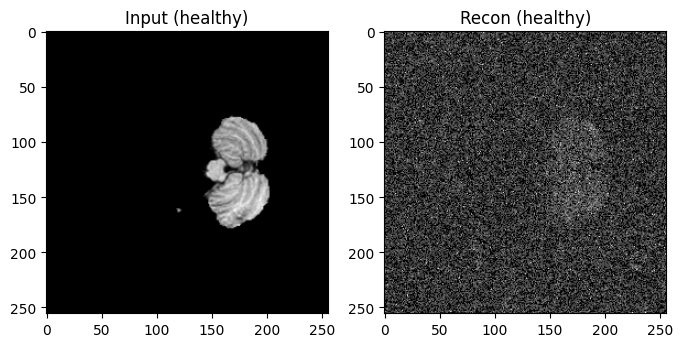

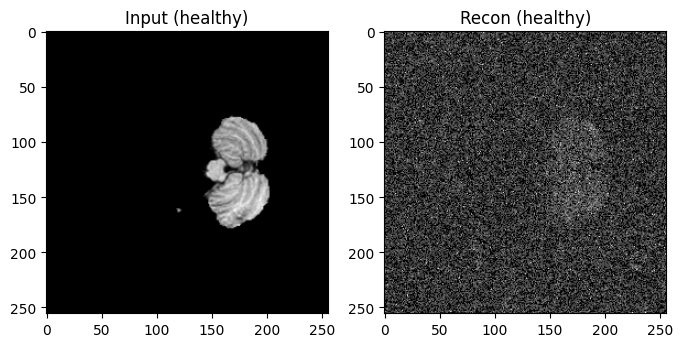

In [38]:
# Quick recon sanity check on a HEALTHY val slice
# Load any slice from slices0 that has seg==0
healthy_idx = next(i for i, s in enumerate(segs0) if s.max() == 0)
x_h = torch.from_numpy(slices0[healthy_idx])[None].to(DEVICE).float()
x_hat_h = ddim_reconstruct(x_h, encode_t=400, n_steps=1000)  # use ddim now

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(x_h[0,0].cpu().numpy(), cmap='gray'); ax[0].set_title('Input (healthy)')
ax[1].imshow(x_hat_h[0,0].cpu().numpy(), cmap='gray'); ax[1].set_title('Recon (healthy)')
plt.show()

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(x_h[0,0].cpu().numpy(), cmap='gray'); ax[0].set_title('Input (healthy)')
ax[1].imshow(x_hat_h[0,0].cpu().numpy(), cmap='gray'); ax[1].set_title('Recon (healthy)')
plt.show()

In [39]:
for i, (sl, seg) in enumerate(zip(slices0[:5], segs0[:5])):
    brain_fill = (sl[0] > 0.02).mean()
    tumour_px  = (seg[0] > 0).sum()
    print(f"idx={i}  z={z_ids0[i]}  brain_fill={brain_fill:.2%}  tumour_px={tumour_px}")

idx=0  z=23  brain_fill=7.05%  tumour_px=0
idx=1  z=24  brain_fill=7.53%  tumour_px=0
idx=2  z=25  brain_fill=8.02%  tumour_px=0
idx=3  z=26  brain_fill=8.46%  tumour_px=0
idx=4  z=27  brain_fill=8.87%  tumour_px=0


In [40]:
# Is the model actually predicting anything?
x_test = torch.randn(1, 1, 256, 256, device=DEVICE, dtype=DTYPE)
t_test = torch.tensor([250], device=DEVICE, dtype=torch.long)

with torch.no_grad():
    pred = unet(x_test, t_test)

print(f"noise_pred  mean={pred.mean().item():.4f}  std={pred.std().item():.4f}  "
      f"min={pred.min().item():.4f}  max={pred.max().item():.4f}")

noise_pred  mean=0.0047  std=1.0312  min=-4.2500  max=4.3438


In [41]:
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print("Checkpoint keys:", list(ckpt.keys()))
print("Epoch:", ckpt.get('epoch'))

# Check which state dict key exists
for k in ['unet', 'unet_full', 'model', 'state_dict', 'model_state_dict']:
    if k in ckpt:
        sd = ckpt[k]
        first_key = next(iter(sd))
        first_val = sd[first_key]
        print(f"  key='{k}'  n_params={len(sd)}  "
              f"first_tensor: {first_key} {first_val.shape} dtype={first_val.dtype}")

Checkpoint keys: ['epoch', 'unet', 'optimizer', 'train_losses', 'val_losses']
Epoch: 77
  key='unet'  n_params=224  first_tensor: conv_in.conv.weight torch.Size([64, 1, 3, 3]) dtype=torch.float32


In [42]:
# What does your training script use?
# Print the actual alpha_cumprod values at a few timesteps
alphas = ddpm_scheduler.alphas_cumprod
print("alpha_cumprod at t=0:  ", alphas[0].item())
print("alpha_cumprod at t=250:", alphas[250].item())
print("alpha_cumprod at t=500:", alphas[500].item())
print("alpha_cumprod at t=999:", alphas[999].item())

alpha_cumprod at t=0:   0.9998999834060669
alpha_cumprod at t=250: 0.5214229822158813
alpha_cumprod at t=500: 0.07779665291309357
alpha_cumprod at t=999: 4.035830352222547e-05


In [43]:
# Does x_cur actually change during denoising?
ddpm_scheduler.set_timesteps(250)
x0_scaled = x_h * 2.0 - 1.0
noise = torch.randn_like(x0_scaled)
x_t = ddpm_scheduler.add_noise(x0_scaled, noise, torch.tensor([250], device=DEVICE))

x_cur = x_t.to(DTYPE)
for step_i, t_val in enumerate(range(250, 245, -1)):
    t_batch = torch.full((1,), t_val, device=DEVICE, dtype=torch.long)
    with torch.no_grad():
        noise_pred = unet(x_cur, t_batch)
    x_prev = ddpm_scheduler.step(noise_pred.float(), t_val, x_cur.float())[0].to(DTYPE)
    print(f"t={t_val}  x_cur std={x_cur.float().std().item():.4f}  "
          f"noise_pred std={noise_pred.float().std().item():.4f}  "
          f"x_prev std={x_prev.float().std().item():.4f}")
    x_cur = x_prev

t=250  x_cur std=0.7102  noise_pred std=0.9045  x_prev std=0.7094
t=249  x_cur std=0.7094  noise_pred std=0.9042  x_prev std=0.7076
t=248  x_cur std=0.7076  noise_pred std=0.9041  x_prev std=0.7063
t=247  x_cur std=0.7063  noise_pred std=0.9035  x_prev std=0.7051
t=246  x_cur std=0.7051  noise_pred std=0.9038  x_prev std=0.7039


## 7 · `hybrid_sample` — per-pixel DDPM/DDIM blending

At **every timestep** `t`:

1. Forward the current `x_t` through the UNet → `noise_pred`
2. Compute **DDPM** step → `x_ddpm` (stochastic, adds Gaussian noise)
3. Compute **DDIM** step → `x_ddim` (deterministic, no added noise)
4. Blend per-pixel: `x_{t-1} = mask * x_ddpm + (1 − mask) * x_ddim`

Inside the saliency mask the model must regenerate healthy anatomy from scratch
(stochastic).  Outside the mask the deterministic DDIM step preserves already-
healthy structure more accurately.

In [44]:
@torch.no_grad()
def hybrid_sample(x_t: torch.Tensor,
                  mask: torch.Tensor,
                  encode_t: int    = T_ENCODE,
                  n_ddim_steps: int = N_DDIM_STEPS) -> torch.Tensor:
    """
    Hybrid DDPM (inside mask) / DDIM (outside mask) reverse diffusion.

    Parameters
    ----------
    x_t          : (1,1,256,256) noised image at timestep encode_t, float32
    mask         : (1,1,256,256) float32 binary saliency mask on DEVICE
    encode_t     : timestep to start denoising from
    n_ddim_steps : number of DDIM timestep intervals (higher = sharper/slower)

    Returns
    -------
    x_hat : (1,1,256,256) float32 healthy reconstruction
    """
    # build a sub-set of DDIM timesteps that span [encode_t, 0]
    # DDIMScheduler.set_timesteps picks uniformly-spaced steps over [0, T)
    # we then keep only those <= encode_t
    ddim_scheduler.set_timesteps(n_ddim_steps)
    timesteps = [int(t) for t in ddim_scheduler.timesteps if int(t) <= encode_t]
    if not timesteps:
        timesteps = list(range(encode_t, -1, -1))

    x_cur = x_t.to(DTYPE)
    mask_f = mask.float()

    for t_val in timesteps:
        t_batch = torch.full((x_cur.shape[0],), t_val, device=DEVICE, dtype=torch.long)

        # ── shared noise prediction ──────────────────────────────────────────
        noise_pred = unet(x_cur, t_batch).float()   # (1,1,256,256)
        x_cur_f    = x_cur.float()

        # ── DDIM step (deterministic) ────────────────────────────────────────
        x_ddim = ddim_scheduler.step(noise_pred, t_val, x_cur_f)[0]

        # ── DDPM step (stochastic) ───────────────────────────────────────────
        x_ddpm = ddpm_scheduler.step(noise_pred, t_val, x_cur_f)[0]

        # ── per-pixel blend ──────────────────────────────────────────────────
        # inside mask  → stochastic DDPM  (regenerate healthy anatomy)
        # outside mask → deterministic DDIM (preserve healthy structure)
        x_cur = (mask_f * x_ddpm + (1.0 - mask_f) * x_ddim).to(DTYPE)

    x_hat = ((x_cur.float() + 1.0) / 2.0).clamp(0.0, 1.0)
    return x_hat

## 8 · Pass 2 — saliency-guided hybrid inference

In [ ]:
@torch.no_grad()
def pass2_reconstruct(x0: torch.Tensor,
                      saliency_mask: torch.Tensor,
                      encode_t: int    = T_ENCODE,
                      n_ddim_steps: int = N_DDIM_STEPS) -> torch.Tensor:
    """
    Pass 2: add noise → hybrid_sample with saliency mask.

    Parameters
    ----------
    x0            : (1,1,256,256) float32, values in [0,1]
    saliency_mask : (1,1,256,256) float32 {0,1} from build_saliency_mask()
    encode_t      : noise level
    n_ddim_steps  : DDIM step count for the hybrid decoder

    Returns
    -------
    x_hat_clean : (1,1,256,256) float32 cleaned-up reconstruction
    """
    x0_scaled = x0 * 2.0 - 1.0
    noise     = generate_simplex_noise(x0_scaled.shape, device=DEVICE)
    t_vec     = torch.tensor([encode_t], device=DEVICE).long()
    x_t       = ddpm_scheduler.add_noise(x0_scaled, noise, t_vec)

    x_hat_clean = hybrid_sample(
        x_t, saliency_mask,
        encode_t=encode_t,
        n_ddim_steps=n_ddim_steps,
    )
    return x_hat_clean

## 9 · Full two-pass pipeline wrapper

`run_inference()` respects the `USE_SALIENCY` flag.  Set it to `False` and
you get the original single-pass pipeline (Pass 1 only).

In [46]:
def run_inference(x0: torch.Tensor,
                  use_saliency: bool = USE_SALIENCY,
                  encode_t: int = T_ENCODE,
                  n_ddim_steps: int = N_DDIM_STEPS,
                  thresh_method: str = THRESH_METHOD,
                  fixed_thresh: float = FIXED_THRESH,
                  smooth_sigma: float = SMOOTH_SIGMA):
    """
    Full inference pipeline for one slice.

    Parameters
    ----------
    x0           : (1,1,256,256) float32 on DEVICE, values in [0,1]
    use_saliency : True  → two-pass (Pass1 + Pass2)
                   False → single-pass DDPM only

    Returns dict with keys:
      'amap_rough'     : (256,256) float32  — Pass 1 anomaly map
      'saliency_mask'  : (256,256) float32  — binary mask (None if use_saliency=False)
      'thresh_val'     : float              — threshold used
      'amap_clean'     : (256,256) float32  — Pass 2 anomaly map (=amap_rough if no saliency)
      'x_hat_rough'    : (1,1,256,256) float32
      'x_hat_clean'    : (1,1,256,256) float32
    """
    # ── Pass 1: full-image DDPM reconstruction ────────────────────────────────
    x_hat_rough = ddim_reconstruct(x0, encode_t=encode_t, n_steps=n_ddim_steps)
    amap_rough  = anomaly_map(x0, x_hat_rough, smooth_sigma=smooth_sigma)

    if not use_saliency:
        return dict(
            amap_rough   =amap_rough,
            saliency_mask=None,
            thresh_val   =None,
            amap_clean   =amap_rough,
            x_hat_rough  =x_hat_rough,
            x_hat_clean  =x_hat_rough,
        )

    # ── Build saliency mask from Pass 1 ──────────────────────────────────────
    mask_t, thresh_val = build_saliency_mask(
        amap_rough, method=thresh_method, fixed_val=fixed_thresh
    )

    # ── Pass 2: hybrid DDPM/DDIM with saliency mask ───────────────────────────
    x_hat_clean = pass2_reconstruct(
        x0, mask_t, encode_t=encode_t, n_ddim_steps=n_ddim_steps
    )
    amap_clean = anomaly_map(x0, x_hat_clean, smooth_sigma=smooth_sigma)

    return dict(
        amap_rough   =amap_rough,
        saliency_mask=mask_t[0, 0].cpu().numpy(),   # (256,256)
        thresh_val   =thresh_val,
        amap_clean   =amap_clean,
        x_hat_rough  =x_hat_rough,
        x_hat_clean  =x_hat_clean,
    )

## 10 · Single-slice demo

In [47]:
# ── load one case, pick the most tumour-heavy slice ───────────────────────────
demo_case = all_cases[0]
slices0, z_ids0 = preprocess_volume(demo_case['t1_path'])
segs0           = preprocess_seg(demo_case['seg_path'], z_ids0)

tumor_load = [s.sum() for s in segs0]
best_z     = int(np.argmax(tumor_load))

x0_np  = slices0[best_z]   # (1,256,256)
seg_np = segs0[best_z]     # (1,256,256)

x0 = torch.from_numpy(x0_np)[None].to(DEVICE).float()   # (1,1,256,256)

print(f'Case : {demo_case["id"]}   z={z_ids0[best_z]}')
print(f'Tumour pixels: {(seg_np > 0).sum()}')

# ── show threshold comparison on this slice before running full inference ─────
# (uses a quick cheap anomaly map; replace with Pass-1 output after inference)
print('\nThreshold comparison table (will update after Pass 1 runs):')

Case : BraTS20_Training_001   z=67
Tumour pixels: 5725

Threshold comparison table (will update after Pass 1 runs):


In [48]:
# ── run the full pipeline ─────────────────────────────────────────────────────
# This cell takes ~1-3 min on an RTX 5090 for T_ENCODE=500.
# Reduce T_ENCODE or increase N_DDIM_STEPS for faster/better quality trade-off.

result = run_inference(x0, use_saliency=USE_SALIENCY)

amap_rough    = result['amap_rough']
saliency_mask = result['saliency_mask']
thresh_val    = result['thresh_val']
amap_clean    = result['amap_clean']
x_hat_rough   = result['x_hat_rough']
x_hat_clean   = result['x_hat_clean']

print(f'Pass 1 anomaly map — min={amap_rough.min():.4f}  max={amap_rough.max():.4f}')
if USE_SALIENCY:
    pct_pos = 100.0 * saliency_mask.mean()
    print(f'Saliency mask thresh={thresh_val:.4f}  ({pct_pos:.1f}% positive pixels)')
    print(f'Pass 2 anomaly map — min={amap_clean.min():.4f}  max={amap_clean.max():.4f}')

Pass 1 anomaly map — min=0.0000  max=0.2970
Saliency mask thresh=0.0400  (20.6% positive pixels)
Pass 2 anomaly map — min=0.0000  max=0.2719


In [49]:
# ── threshold comparison table (now with Pass-1 amap) ────────────────────────
gt_binary = (seg_np[0] > 0).astype(np.float32)
compare_thresholds(amap_rough, gt_mask=gt_binary)

   Threshold    % pos    Method     DSC
-------------------------------------------
      0.0200    26.52%     fixed   0.489
      0.0400    18.73%     fixed   0.528
      0.0505    15.42%      OTSU   0.522
      0.0600    12.78%     fixed   0.504
      0.0800     8.55%     fixed   0.425
      0.1000     5.51%     fixed   0.304
      0.1200     3.40%     fixed   0.168
      0.1400     2.04%     fixed   0.074
      0.1600     1.22%     fixed   0.025
      0.1800     0.75%     fixed   0.008
      0.2000     0.44%     fixed   0.001
      0.2200     0.19%     fixed   0.000
      0.2400     0.09%     fixed   0.000


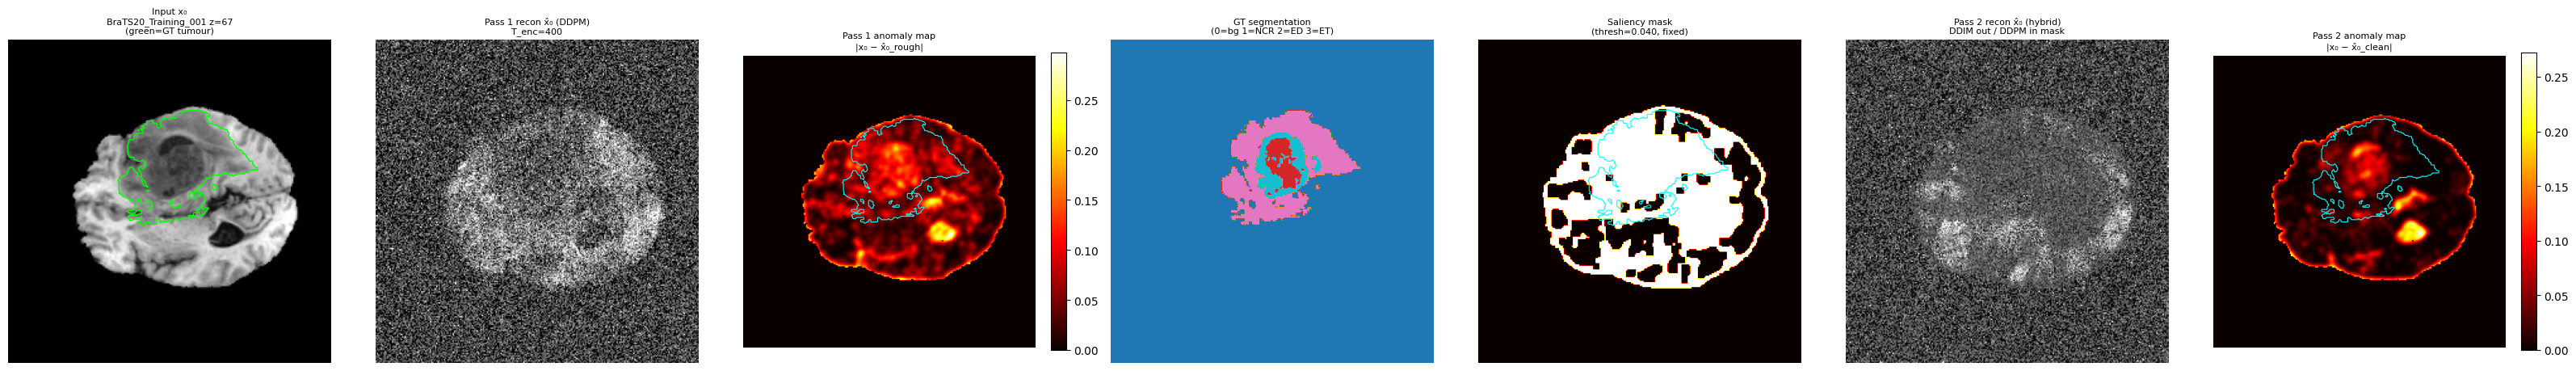

Saved → saliency_demo.png


In [50]:
# ── visualisation ─────────────────────────────────────────────────────────────
seg_plot = seg_np[0]                              # (256,256)
gt_cont  = (seg_plot > 0).astype(np.float32)

if USE_SALIENCY:
    fig, axes = plt.subplots(1, 7, figsize=(32, 5))
else:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

ax = axes

# 0 — input
ax[0].imshow(x0[0,0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax[0].contour(gt_cont, levels=[0.5], colors='lime', linewidths=1)
ax[0].set_title(f'Input x₀\n{demo_case["id"]} z={z_ids0[best_z]}\n(green=GT tumour)', fontsize=8)

# 1 — Pass 1 reconstruction
ax[1].imshow(x_hat_rough[0,0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax[1].set_title(f'Pass 1 recon x̂₀ (DDPM)\nT_enc={T_ENCODE}', fontsize=8)

# 2 — Pass 1 anomaly map
im2 = ax[2].imshow(amap_rough, cmap='hot', vmin=0)
ax[2].contour(gt_cont, levels=[0.5], colors='cyan', linewidths=0.8)
ax[2].set_title('Pass 1 anomaly map\n|x₀ − x̂₀_rough|', fontsize=8)
fig.colorbar(im2, ax=ax[2], fraction=0.046)

# 3 — GT seg
ax[3].imshow(seg_plot, cmap='tab10', vmin=0, vmax=3)
ax[3].set_title('GT segmentation\n(0=bg 1=NCR 2=ED 3=ET)', fontsize=8)

if USE_SALIENCY:
    # 4 — saliency mask
    ax[4].imshow(saliency_mask, cmap='hot', vmin=0, vmax=1)
    ax[4].contour(gt_cont, levels=[0.5], colors='cyan', linewidths=0.8)
    ax[4].set_title(f'Saliency mask\n(thresh={thresh_val:.3f}, {THRESH_METHOD})', fontsize=8)

    # 5 — Pass 2 reconstruction
    ax[5].imshow(x_hat_clean[0,0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax[5].set_title('Pass 2 recon x̂₀ (hybrid)\nDDIM out / DDPM in mask', fontsize=8)

    # 6 — Pass 2 anomaly map
    im6 = ax[6].imshow(amap_clean, cmap='hot', vmin=0)
    ax[6].contour(gt_cont, levels=[0.5], colors='cyan', linewidths=0.8)
    ax[6].set_title('Pass 2 anomaly map\n|x₀ − x̂₀_clean|', fontsize=8)
    fig.colorbar(im6, ax=ax[6], fraction=0.046)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.savefig('saliency_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → saliency_demo.png')

## 11 · Batch evaluation — DSC, AUROC, pixel-AP

Runs both the rough (Pass 1 only) and clean (two-pass) pipelines on a set of
BraTS cases and reports slice-level metrics.

In [51]:
def dice(pred_binary: np.ndarray, gt_binary: np.ndarray) -> float:
    inter = (pred_binary * gt_binary).sum()
    return float(2 * inter / max(pred_binary.sum() + gt_binary.sum(), 1e-6))


def best_f1_threshold(amap: np.ndarray, gt_binary: np.ndarray,
                      n_thresholds: int = 50) -> tuple[float, float]:
    """Sweep thresholds and return (best_DSC, best_threshold)."""
    lo, hi = amap.min(), amap.max()
    best_dsc, best_t = 0.0, lo
    for t in np.linspace(lo, hi, n_thresholds):
        d = dice((amap >= t).astype(np.float32), gt_binary)
        if d > best_dsc:
            best_dsc, best_t = d, float(t)
    return best_dsc, best_t



def evaluate_slice(amap: np.ndarray, gt_binary: np.ndarray):
    metrics = {}
    flat_amap = amap.flatten()
    flat_gt   = gt_binary.flatten().astype(int)

    if flat_gt.sum() > 0 and flat_gt.sum() < flat_gt.size:
        metrics['auroc']         = roc_auc_score(flat_gt, flat_amap)
        metrics['auroc_flipped'] = roc_auc_score(flat_gt, -flat_amap)
        metrics['pixel_ap']      = average_precision_score(flat_gt, flat_amap)
    else:
        metrics['auroc']         = float('nan')
        metrics['auroc_flipped'] = float('nan')
        metrics['pixel_ap']      = float('nan')

    metrics['best_dsc'], metrics['best_thresh'] = best_f1_threshold(amap, gt_binary)

    # DSC at global fixed threshold — the real deployment number
    pred_fixed = (amap >= FIXED_THRESH).astype(np.float32)
    metrics['dsc_fixed'] = dice(pred_fixed, gt_binary)

    try:    otsu_t = threshold_otsu(amap)
    except: otsu_t = FIXED_THRESH
    metrics['dsc_otsu'] = dice((amap >= otsu_t).astype(np.float32), gt_binary)

    return metrics

In [52]:
# ── batch eval config ─────────────────────────────────────────────────────────
N_EVAL_CASES   = 3       # set to None for all cases (slow!)
TUMOR_ONLY     = True    # only evaluate slices that contain tumour

eval_cases = all_cases[:N_EVAL_CASES] if N_EVAL_CASES else all_cases
eval_ds    = BraTSDataset(eval_cases, tumor_only=TUMOR_ONLY)
eval_dl    = DataLoader(eval_ds, batch_size=1, shuffle=False,
                        num_workers=0, collate_fn=brats_collate)

print(f'Evaluating on {len(eval_ds)} tumor slices from {len(eval_cases)} cases')

Indexing 3 BraTS cases (lazy -- fast) ...


Index built: 190 slices (190 with tumour)
Evaluating on 190 tumor slices from 3 cases


In [53]:
rows_rough, rows_clean = [], []

for i, batch in enumerate(eval_dl):
    x0_b  = batch['image'].to(DEVICE).float()    # (1,1,256,256)
    gt_b  = batch['seg'][0, 0]                   # (256,256) int32
    gt_bi = (gt_b > 0).astype(np.float32)

    res = run_inference(x0_b, use_saliency=USE_SALIENCY)

    m_rough = evaluate_slice(res['amap_rough'], gt_bi)
    m_clean = evaluate_slice(res['amap_clean'], gt_bi)

    rows_rough.append(m_rough)
    rows_clean.append(m_clean)

    tag = '[saliency]' if USE_SALIENCY else '[single-pass]'
    print(f'  [{i+1}/{len(eval_dl)}] {batch["case"][0]} z={batch["z_idx"][0]}  '
          f'rough AUROC={m_rough["auroc"]:.3f}  '
          f'clean AUROC={m_clean["auroc"]:.3f}  {tag}')

print('Done.')

  [1/190] BraTS20_Training_001 z=30  rough AUROC=0.985  clean AUROC=0.985  [saliency]
  [2/190] BraTS20_Training_001 z=31  rough AUROC=0.975  clean AUROC=0.964  [saliency]
  [3/190] BraTS20_Training_001 z=32  rough AUROC=0.956  clean AUROC=0.969  [saliency]
  [4/190] BraTS20_Training_001 z=33  rough AUROC=0.959  clean AUROC=0.956  [saliency]
  [5/190] BraTS20_Training_001 z=34  rough AUROC=0.945  clean AUROC=0.961  [saliency]
  [6/190] BraTS20_Training_001 z=35  rough AUROC=0.954  clean AUROC=0.939  [saliency]
  [7/190] BraTS20_Training_001 z=36  rough AUROC=0.965  clean AUROC=0.938  [saliency]
  [8/190] BraTS20_Training_001 z=37  rough AUROC=0.959  clean AUROC=0.943  [saliency]
  [9/190] BraTS20_Training_001 z=38  rough AUROC=0.960  clean AUROC=0.934  [saliency]
  [10/190] BraTS20_Training_001 z=39  rough AUROC=0.952  clean AUROC=0.947  [saliency]
  [11/190] BraTS20_Training_001 z=40  rough AUROC=0.953  clean AUROC=0.941  [saliency]
  [12/190] BraTS20_Training_001 z=41  rough AUROC=0.

In [54]:
# ── summary table ─────────────────────────────────────────────────────────────
def nanmean(vals):
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else float('nan')

metrics_to_show = ['auroc', 'pixel_ap', 'best_dsc', 'dsc_otsu']

print(f'\n{'Metric':>14}  {'Rough (P1)':>12}  {'Clean (P2)':>12}  {'Delta':>8}')
print('-' * 52)
for m in metrics_to_show:
    r = nanmean([row[m] for row in rows_rough])
    c = nanmean([row[m] for row in rows_clean])
    delta = c - r
    print(f'{m:>14}  {r:>12.4f}  {c:>12.4f}  {delta:>+8.4f}')


        Metric    Rough (P1)    Clean (P2)     Delta
----------------------------------------------------
         auroc        0.9079        0.9022   -0.0058
      pixel_ap        0.1575        0.1441   -0.0134
      best_dsc        0.2522        0.2280   -0.0242
      dsc_otsu        0.2169        0.1228   -0.0941


In [55]:
metrics_to_show = ['auroc', 'auroc_flipped', 'pixel_ap', 'best_dsc', 'dsc_fixed']
def nanmean(vals):
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else float('nan')

print(f"{'Metric':>16}  {'Rough (P1)':>12}  {'Clean (P2)':>12}")
print('-' * 46)
for m in metrics_to_show:
    r = nanmean([row.get(m, float('nan')) for row in rows_rough])
    c = nanmean([row.get(m, float('nan')) for row in rows_clean])
    print(f"{m:>16}  {r:>12.4f}  {c:>12.4f}")

          Metric    Rough (P1)    Clean (P2)
----------------------------------------------
           auroc        0.9079        0.9022
   auroc_flipped        0.0921        0.0978
        pixel_ap        0.1575        0.1441
        best_dsc        0.2522        0.2280
       dsc_fixed        0.2207        0.1635


<module 'matplotlib.pyplot' from '/workspace/Brats/venv/lib/python3.12/site-packages/matplotlib/pyplot.py'>

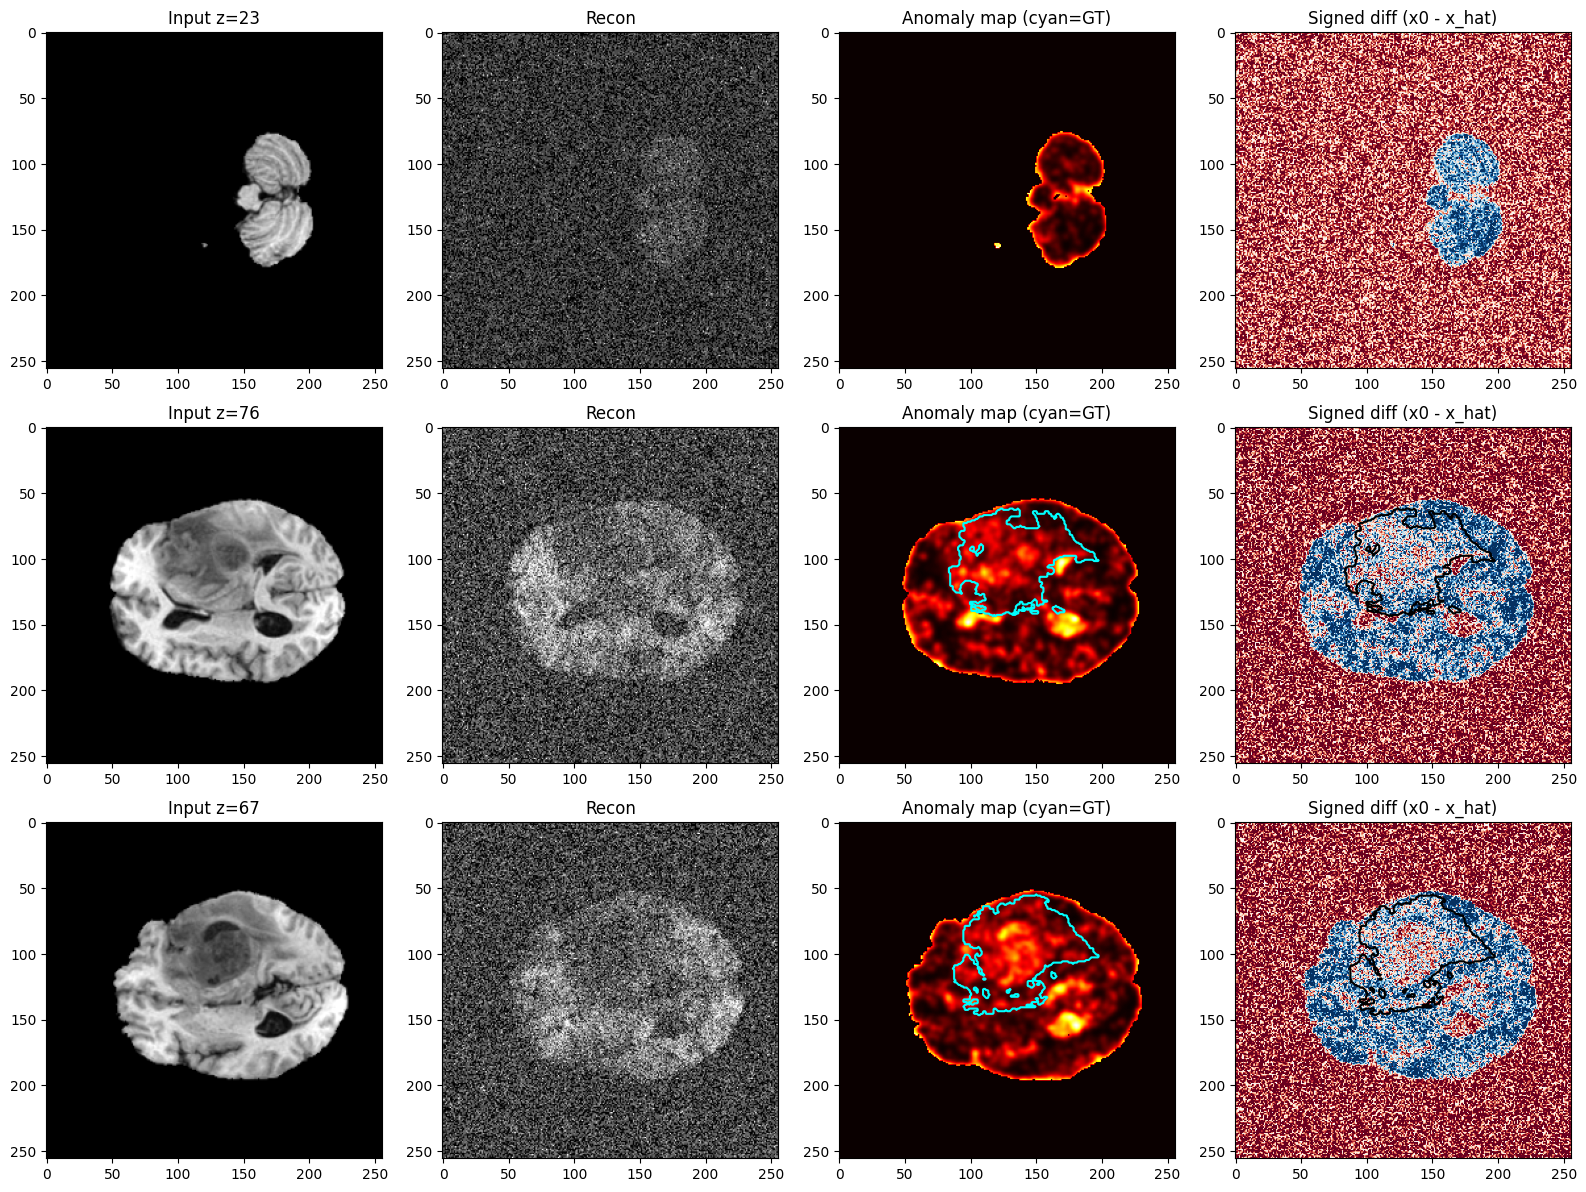

In [56]:
# Pick 3 slices: low, mid, high tumour burden
test_indices = [0, len(slices0)//2, best_z]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, idx in enumerate(test_indices):
    x_t = torch.from_numpy(slices0[idx])[None].to(DEVICE).float()
    seg_t = segs0[idx][0]
    
    x_hat = ddim_reconstruct(x_t, encode_t=400, n_steps=1000)
    amap  = anomaly_map(x_t, x_hat, smooth_sigma=2.0)
    
    gt = (seg_t > 0).astype(np.float32)
    
    axes[row,0].imshow(x_t[0,0].cpu().numpy(), cmap='gray')
    axes[row,0].set_title(f'Input z={z_ids0[idx]}')
    
    axes[row,1].imshow(x_hat[0,0].cpu().numpy(), cmap='gray')
    axes[row,1].set_title('Recon')
    
    axes[row,2].imshow(amap, cmap='hot')
    axes[row,2].contour(gt, levels=[0.5], colors='cyan')
    axes[row,2].set_title(f'Anomaly map (cyan=GT)')
    
    diff_signed = (x_t[0,0].cpu().numpy() - x_hat[0,0].cpu().numpy())
    axes[row,3].imshow(diff_signed, cmap='RdBu', vmin=-0.3, vmax=0.3)
    axes[row,3].contour(gt, levels=[0.5], colors='black')
    axes[row,3].set_title('Signed diff (x0 - x_hat)')

plt.tight_layout()
plt

In [57]:
# best_z slice with tumour
x_h_tumour = torch.from_numpy(slices0[best_z])[None].to(DEVICE).float()
seg_best   = segs0[best_z][0]   # (256,256)

# sweep
for t_enc in [100, 200, 300, 400]:
    x_hat = ddim_reconstruct(x_h_tumour, encode_t=t_enc, n_steps=1000)
    amap  = anomaly_map(x_h_tumour, x_hat, smooth_sigma=2.0)
    gt_bi = (seg_best > 0).astype(np.float32)
    from sklearn.metrics import roc_auc_score
    auroc = roc_auc_score(gt_bi.flatten(), amap.flatten())
    print(f"T_ENCODE={t_enc:4d}  AUROC={auroc:.4f}  amap_max={amap.max():.4f}")

T_ENCODE= 100  AUROC=0.9021  amap_max=0.0889
T_ENCODE= 200  AUROC=0.9083  amap_max=0.1278


T_ENCODE= 300  AUROC=0.9035  amap_max=0.1794
T_ENCODE= 400  AUROC=0.9199  amap_max=0.3022


In [58]:
# Test T_ENCODE across multiple tumour slices
from sklearn.metrics import roc_auc_score

# pick ~10 slices spread across the tumour-containing range
tumour_indices = [i for i, s in enumerate(segs0) if s.max() > 0]
test_idxs = tumour_indices[::len(tumour_indices)//10][:10]

results = {t: [] for t in [100, 200, 300, 400]}

for idx in test_idxs:
    x_t  = torch.from_numpy(slices0[idx])[None].to(DEVICE).float()
    gt_b = (segs0[idx][0] > 0).astype(np.float32)
    if gt_b.sum() < 10:
        continue
    for t_enc in [100, 200, 300, 400]:
        x_hat = ddim_reconstruct(x_t, encode_t=t_enc, n_steps=1000)
        amap  = anomaly_map(x_t, x_hat, smooth_sigma=2.0)
        auroc = roc_auc_score(gt_b.flatten(), amap.flatten())
        results[t_enc].append(auroc)

print(f"{'T_ENCODE':>10}  {'mean AUROC':>12}  {'min':>8}  {'max':>8}  {'n':>4}")
print('-' * 50)
for t_enc, vals in results.items():
    print(f"{t_enc:>10}  {np.mean(vals):>12.4f}  {np.min(vals):>8.4f}  {np.max(vals):>8.4f}  {len(vals):>4}")

  T_ENCODE    mean AUROC       min       max     n
--------------------------------------------------
       100        0.9076    0.8833    0.9449     9
       200        0.9162    0.8710    0.9559     9
       300        0.9164    0.8790    0.9581     9
       400        0.9272    0.9009    0.9612     9


In [59]:
for sigma in [2.0, 4.0, 6.0, 8.0]:
    amap = anomaly_map(x_h_tumour, x_hat, smooth_sigma=sigma)
    auroc = roc_auc_score((seg_best > 0).flatten(), amap.flatten())
    dsc, _ = best_f1_threshold(amap, (seg_best > 0).astype(np.float32))
    print(f"sigma={sigma:.1f}  AUROC={auroc:.4f}  best_DSC={dsc:.4f}")

sigma=2.0  AUROC=0.9560  best_DSC=0.6419
sigma=4.0  AUROC=0.9585  best_DSC=0.6466
sigma=6.0  AUROC=0.9599  best_DSC=0.6385
sigma=8.0  AUROC=0.9611  best_DSC=0.6409


In [60]:
from sklearn.metrics import roc_auc_score

all_amaps = []
all_gts   = []

tumour_indices = [i for i, s in enumerate(segs0) if s.max() > 0]
test_idxs = tumour_indices[::len(tumour_indices)//10][:10]

for idx in test_idxs:
    x_t  = torch.from_numpy(slices0[idx])[None].to(DEVICE).float()
    gt_b = (segs0[idx][0] > 0).astype(np.float32)
    if gt_b.sum() < 10:
        continue
    x_hat = ddim_reconstruct(x_t, encode_t=400, n_steps=1000)
    amap  = anomaly_map(x_t, x_hat, smooth_sigma=2.0)
    all_amaps.append(amap)
    all_gts.append(gt_b)

# sweep global threshold
all_amaps_np = np.stack(all_amaps)
all_gts_np   = np.stack(all_gts)

print(f"{'Threshold':>10}  {'mean DSC':>10}  {'min DSC':>8}")
print('-' * 35)
for t in np.arange(0.01, 0.15, 0.01):
    dscs = []
    for amap, gt in zip(all_amaps_np, all_gts_np):
        pred = (amap >= t).astype(np.float32)
        inter = (pred * gt).sum()
        d = 2 * inter / max(pred.sum() + gt.sum(), 1e-6)
        dscs.append(d)
    print(f"{t:>10.3f}  {np.mean(dscs):>10.4f}  {np.min(dscs):>8.4f}")

 Threshold    mean DSC   min DSC
-----------------------------------
     0.010      0.3218    0.1505
     0.020      0.3506    0.1891
     0.030      0.3716    0.1969
     0.040      0.3766    0.1841
     0.050      0.3637    0.1511
     0.060      0.3326    0.1186
     0.070      0.2943    0.0771
     0.080      0.2525    0.0452
     0.090      0.2114    0.0325
     0.100      0.1734    0.0231
     0.110      0.1416    0.0167
     0.120      0.1159    0.0132
     0.130      0.0903    0.0061
     0.140      0.0704    0.0022
